In [48]:
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, KFold
from imblearn.combine import SMOTETomek
from sklearn.metrics import recall_score, f1_score, precision_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


In [49]:
data_path = "healthcare_dataset.csv"

df = pd.read_csv(data_path)

df.head(10)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
5,EMILY JOHNSOn,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,389,Urgent,2023-12-24,Ibuprofen,Normal
6,edwArD EDWaRDs,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.872345,389,Emergency,2020-11-15,Paracetamol,Inconclusive
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal
9,ChRISTopher BerG,58,Female,AB-,Cancer,2021-05-23,Heather Day,Padilla-Walker,UnitedHealthcare,19784.631062,249,Elective,2021-06-22,Paracetamol,Inconclusive


In [50]:
# Checking missing values

print(f"Reading Missing Values : {df.isnull().sum().max()}")

Reading Missing Values : 0


In [51]:
# Reading data types 

df.dtypes

Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

In [52]:
uni_cols = [
    'Name', 
    'Gender', 
    'Blood Type', 
    'Medical Condition', 
    'Date of Admission', 
    'Doctor', 
    'Hospital', 
    'Insurance Provider', 
    'Admission Type', 
    'Medication', 
    'Test Results'
    ]

for i, col_name in enumerate(uni_cols):
    uni_count = df[col_name].unique()
    print(f"Index {i} with unique : {uni_count}")

Index 0 with unique : <StringArray>
[     'Bobby JacksOn',       'LesLie TErRy',        'DaNnY sMitH',
       'andrEw waTtS',      'adrIENNE bEll',      'EMILY JOHNSOn',
     'edwArD EDWaRDs', 'CHrisTInA MARtinez',    'JASmINe aGuIlaR',
   'ChRISTopher BerG',
 ...
   'tamAra MCcOrmIck',        'sara TAYloR',     'REbECcA toRReS',
       'JAMes lITTLe',      'CaRl CHaNDlEr',        'JOSepH PaUl',
     'braDleY dAniEL',       'LiSa sIMPsoN',      'RoGER farRELl',
  'kaTheRIne WeBSTer']
Length: 49992, dtype: str
Index 1 with unique : <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Index 2 with unique : <StringArray>
['B-', 'A+', 'A-', 'O+', 'AB+', 'AB-', 'B+', 'O-']
Length: 8, dtype: str
Index 3 with unique : <StringArray>
['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension', 'Arthritis']
Length: 6, dtype: str
Index 4 with unique : <StringArray>
['2024-01-31', '2019-08-20', '2022-09-22', '2020-11-18', '2022-09-19',
 '2023-12-20', '2020-11-03', '2021-12-28', '2020-07-01', '202

In [53]:
# Dropping unused feature 

dfe = df.copy()

dfe = dfe.drop(['Name', 'Doctor', 'Hospital', 'Discharge Date'], axis=1)

dfe.dtypes


Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Medication                str
Test Results              str
dtype: object

In [ ]:
# Visualization compare of placement_status from study_hours and exam_score

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.stripplot(data=df, x='study_hours', y='exam_score', 
              hue='placement_status', alpha=0.3, jitter=True, ax=axes[0])

axes[0].set_title('Study Hours to Exam Score')
axes[0].set_xlabel('study_hours')
axes[0].set_ylabel('exam_score')

sns.boxplot(data=df, x='placement_status', y='exam_score', ax=axes[1], )

axes[1].set_title('Exam Score to Placement')
axes[1].set_xlabel('placement_status')
axes[1].set_ylabel('exam_score')

plt.show()

In [54]:
# Encoding step 

dfe['Gender'] = dfe['Gender'].map({"Male" : 0, "Female" : 1})

dfe['Admission Type'] = dfe['Admission Type'].map({"Elective" : 0, "Urgent" : 1, "Emergency" : 2})

dfe['Test Results'] = dfe['Test Results'].map({"Normal" : 0, "Abnormal" : 1, "Inconclusive" : 2})

dfe['Date of Admission'] = pd.to_datetime(dfe['Date of Admission'])
dfe['Admission_Year']  = dfe['Date of Admission'].dt.year
dfe['Admission_Month'] = dfe['Date of Admission'].dt.month
dfe['Admission_Day']   = dfe['Date of Admission'].dt.dayofweek
dfe = dfe.drop('Date of Admission', axis=1)

ohe_cols = ['Blood Type', 'Medical Condition', 
            'Insurance Provider', 'Medication']
dfe = pd.get_dummies(dfe, columns=ohe_cols, dtype=int)

print(dfe.select_dtypes(include=['str','object']).columns.tolist())
print(dfe.shape)

[]
(55500, 33)


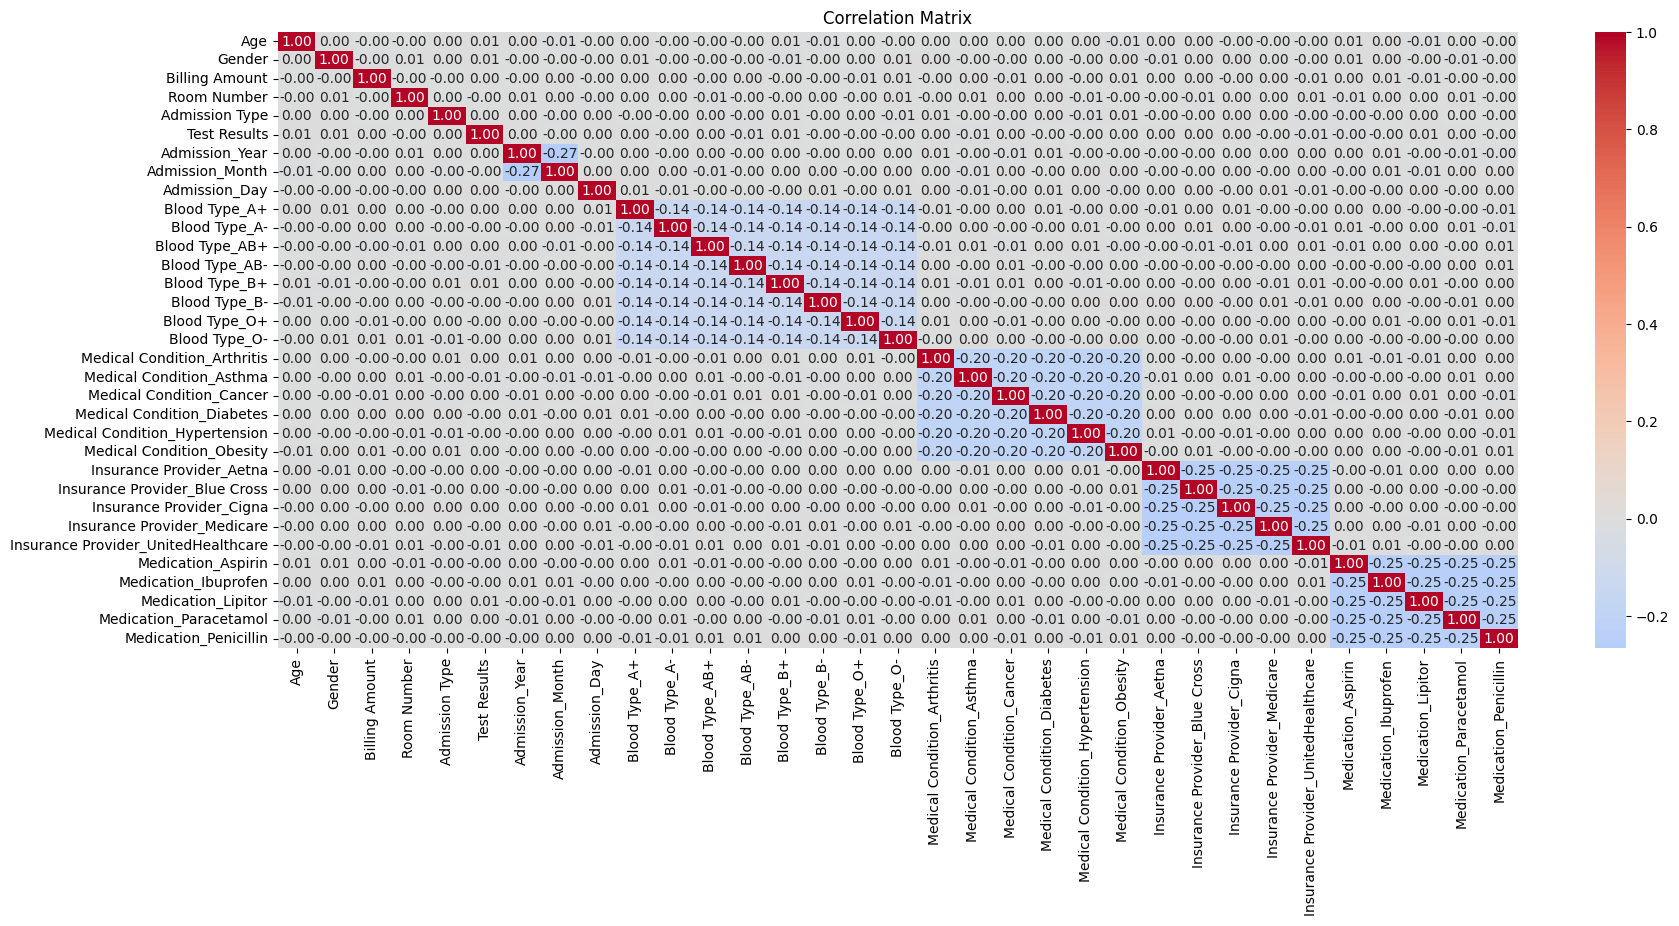

In [ ]:
# Visualization compare of placement_status from study_hours and exam_score

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.stripplot(data=df, x='study_hours', y='exam_score', 
              hue='placement_status', alpha=0.3, jitter=True, ax=axes[0])

axes[0].set_title('Study Hours to Exam Score')
axes[0].set_xlabel('study_hours')
axes[0].set_ylabel('exam_score')

sns.boxplot(data=df, x='placement_status', y='exam_score', ax=axes[1], )

axes[1].set_title('Exam Score to Placement')
axes[1].set_xlabel('placement_status')
axes[1].set_ylabel('exam_score')

plt.show()